In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [3]:
full_inputs_df = pd.read_excel("Materials Dataset.xlsx", sheet_name="Inputs")
full_outputs_df = pd.read_excel("Materials Dataset.xlsx", sheet_name="Outputs")

In [4]:
full_inputs_df

,material,thickness,density,porosity,moisture_abs,CHOL_input
0,Poplar,3.094,279,60.1,6.5,0.784
1,Poplar,3.094,279,60.1,6.5,1.618
2,Poplar,3.094,279,60.1,6.5,3.290
3,Poplar,3.094,279,60.1,6.5,6.144
4,Kapok,4.050,312,65.0,6.5,0.802
5,Kapok,4.050,312,65.0,6.5,1.578
6,Kapok,4.050,312,65.0,6.5,3.165
7,Kapok,4.050,312,65.0,6.5,5.625
8,Milkweed,4.070,317,65.0,6.5,0.790
9,Milkweed,4.070,317,65.0,6.5,1.638


In [5]:
full_outputs_df

,surface_productivity,surface_productivity_SD,biomass_productivity,biomass_productivity_SD,product_conc,product_conc_SD,yield,yield_SD,biomass,biomass_SD
0,12.478,0.348,0.432,0.041,0.809,0.023,103.215,2.880,26.549,2.290
1,22.890,0.922,0.795,0.090,1.484,0.060,91.691,3.694,26.549,2.290
2,42.774,3.040,1.486,0.343,2.772,0.197,84.267,5.989,26.549,2.290
3,20.596,1.982,0.708,0.023,1.335,0.128,21.728,2.091,26.549,2.290
4,12.197,0.792,0.517,0.017,0.826,0.027,102.994,3.408,22.526,0.526
5,20.955,0.846,0.889,0.037,1.421,0.036,90.013,2.307,22.526,0.526
6,34.541,4.217,1.459,0.103,2.334,0.200,73.762,6.318,22.526,0.526
7,15.018,0.876,0.637,0.027,1.018,0.036,18.091,0.646,22.526,0.526
8,12.328,0.854,0.523,0.029,0.835,0.043,105.740,5.455,22.207,1.761
9,21.866,1.139,0.928,0.043,1.482,0.053,90.484,3.246,22.207,1.761


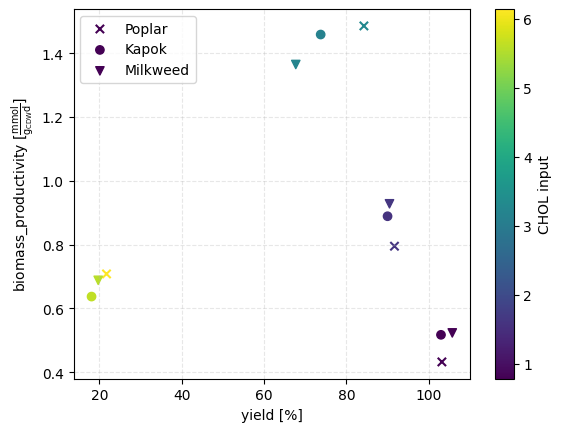

In [6]:
# Select outputs
output_1 = 'yield'
output_2 = 'biomass_productivity'
outputs_df = full_outputs_df[[output_1, output_1 + '_SD', output_2, output_2 + '_SD']]

# Set color mapping for different materials
material_shapes = {'Poplar': 'x', "Kapok": 'o', 'Milkweed': 'v'}

# Set up CHOL values for the colorbar
chol = full_inputs_df['CHOL_input']
norm = mpl.colors.Normalize(vmin = chol.min(), vmax = chol.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots()

# Plot each material separately
for material, mark in material_shapes.items():
    mask = full_inputs_df['material'] == material

    ax.scatter(
        outputs_df.loc[mask, output_1], 
        outputs_df.loc[mask, output_2],
        c=chol.loc[mask],
        cmap=cmap,
        norm=norm, 
        label=material, 
        marker=mark
    )

# Add colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('CHOL input')

ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel(output_1 + ' [%]')
ax.set_ylabel(output_2 + r' [$\frac{\mathrm{mmol}}{\mathrm{g_{CDW} d}}$]')
ax.legend()

plt.show()

/tmp/ipykernel_3100433/1503049124.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(RHO, Z, T, shading="auto", cmap="inferno")
/tmp/ipykernel_3100433/1503049124.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(-RHO, Z, T, shading="auto", cmap="inferno")  # mirror for the full cross-section


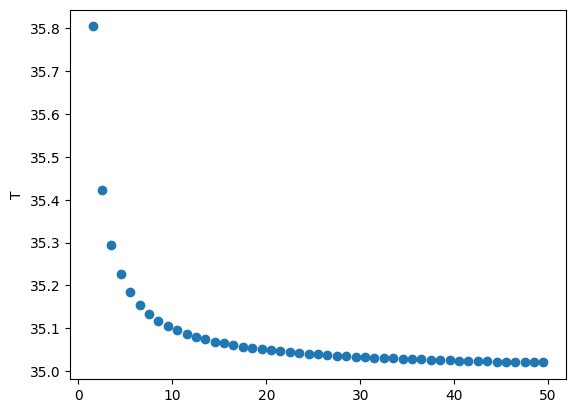

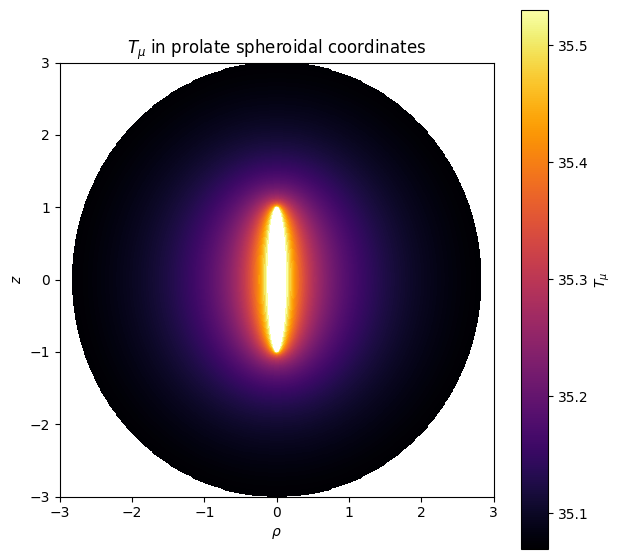

In [28]:
import numpy as np
import matplotlib.pyplot as plt
mu = np.arange(1.5, 50)
T_mu = 35 + np.log((mu + 1) / (mu-1)) * 0.5

plt.scatter(mu, T_mu)
plt.ylabel("T")

a = 1.0  # focal half-distance

# Radial coordinate (xi = cosh(mu) >= 1) and angular coordinate eta = cos(nu) in [-1, 1]
xi  = np.linspace(1.01, 3, 600)
eta = np.linspace(-1, 1, 400)
XI, ETA = np.meshgrid(xi, eta, indexing="ij")

# T depends only on xi
T = 35 + 0.1 * np.log((XI + 1) / (XI - 1))

# Prolate spheroidal -> cylindrical (rho, z)
Z   = a * XI * ETA
RHO = a * np.sqrt((XI**2 - 1) * (1 - ETA**2))

fig, ax = plt.subplots(figsize=(7, 7))
pc = ax.pcolormesh(RHO, Z, T, shading="auto", cmap="inferno")
ax.pcolormesh(-RHO, Z, T, shading="auto", cmap="inferno")  # mirror for the full cross-section

ax.set_aspect("equal")
ax.set_ylim(-3, 3)
ax.set_xlim(-3, 3)
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$z$")
ax.set_title(r"$T_\mu$ in prolate spheroidal coordinates")
fig.colorbar(pc, ax=ax, label=r"$T_\mu$")
plt.show();